In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import seaborn as sns

dfm4 = pd.read_pickle("dfm4.pkl")
dfp2 = pd.read_pickle("dfp2.pkl")

#### Vizualization prep

In [16]:
setValueMagic = dfm4.groupby("setName").agg({
    "avgMarketPrice" : "sum",
    "releaseYear" : "first"
})

# Reset index so setName and releaseYear are columns.
setValueMagicClean = setValueMagic.reset_index()

# Order values.
setValueMagicClean = setValueMagicClean.sort_values(by=["releaseYear", "avgMarketPrice"], ascending = False)

# To show the top sets from each year for graph ax text.
setSumMagic = dfm4.groupby(["releaseYear", "setName"], as_index=False)["avgMarketPrice"].sum()

# For each year, the set with the highest total price.
topSetsMagic = setSumMagic.loc[setSumMagic.groupby("releaseYear")["avgMarketPrice"].idxmax()]
topSetsMagic = topSetsMagic.sort_values("avgMarketPrice").round()
topSetsMagic = topSetsMagic.sort_values("releaseYear")

#### Magic line graph - release year value

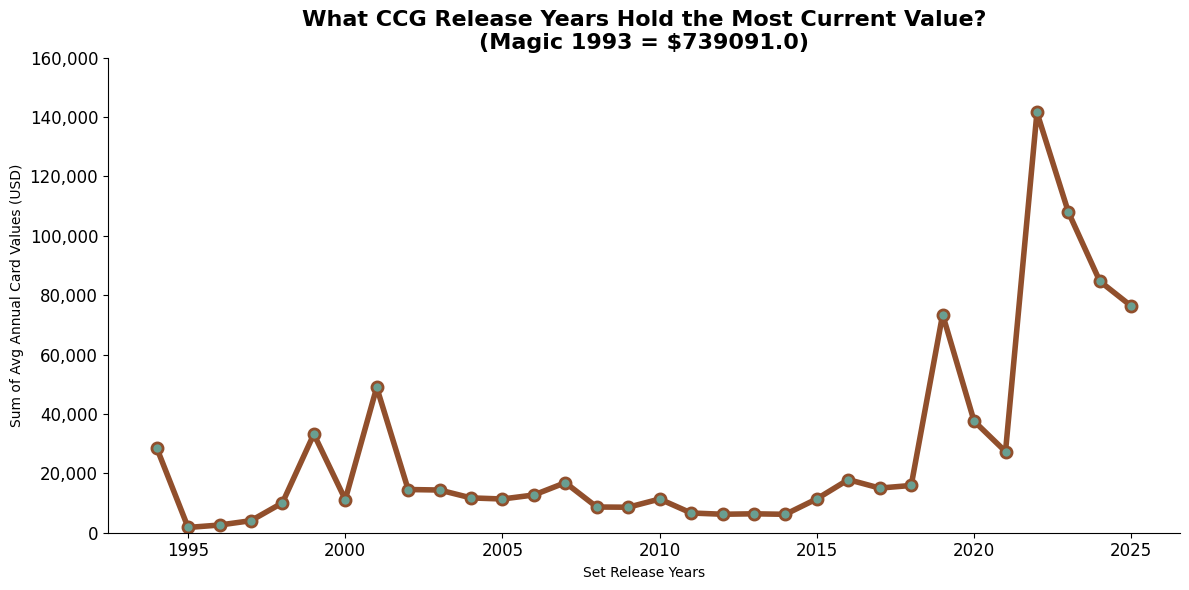

In [17]:
plt.figure(figsize=(12,6))

# 1993 Magic really skews the data, so it will be represented as a f-string in the title.
no1993 = dfm4[dfm4['releaseYear'] != 1993]
sumPerYearNo1993 = no1993.groupby("releaseYear")["avgMarketPrice"].sum().reset_index()

plt.plot(sumPerYearNo1993["releaseYear"], sumPerYearNo1993["avgMarketPrice"], color="#914F2C", linewidth=4, marker="o", markersize = 8, markerfacecolor = "#699F91", markeredgewidth = 2)
plt.ylim(0, 160000)
plt.xlabel("Set Release Years")
plt.ylabel("Sum of Avg Annual Card Values (USD)")

value1993 = dfm4.loc[dfm4["releaseYear"] == 1993, "avgMarketPrice"].sum().round()
plt.title(f"What CCG Release Years Hold the Most Current Value?\n(Magic 1993 = ${value1993})", fontsize=16, fontweight="bold", color="black")

ax = plt.gca()

# Show thousands comma for y-axis.
ax.yaxis.set_major_formatter(tkr.StrMethodFormatter('{x:,.0f}'))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

#### Magic line graph - release year value - Pokemon comparison

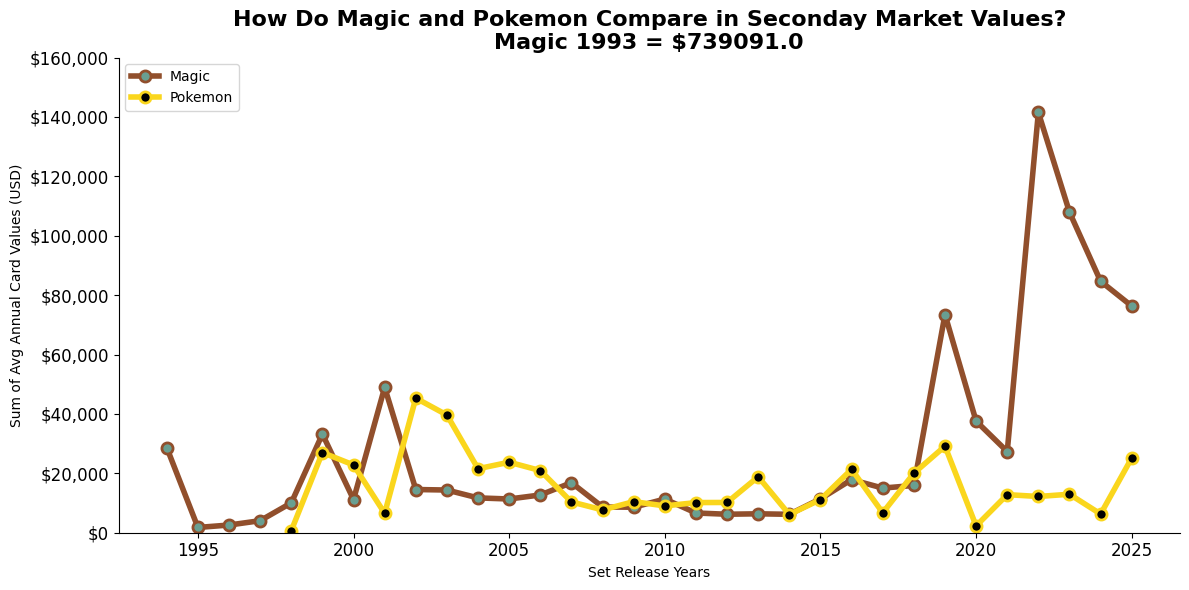

In [18]:
plt.figure(figsize=(12,6))

# 1993 Magic really skews the data, so it will be represented as a f-string in the title.
dfm4No1993 = dfm4[dfm4['releaseYear'] != 1993]

sumPerYearNo1993 = dfm4No1993.groupby("releaseYear")["avgMarketPrice"].sum().reset_index()
sumPerYearPokemon = dfp2.groupby("releaseYear")["marketPrice"].sum().reset_index()

# Plot Magic line.
plt.plot(sumPerYearNo1993["releaseYear"], sumPerYearNo1993["avgMarketPrice"], color="#914F2C", linewidth=4, marker="o", markersize = 8, markerfacecolor = "#699F91", 
         markeredgewidth = 2, label = 'Magic')

# Plot Pokemon line.
plt.plot(sumPerYearPokemon["releaseYear"], sumPerYearPokemon["marketPrice"], color="#FAD61D", linewidth=4, marker="o", markersize = 8, markerfacecolor = "#000000", 
         markeredgewidth = 2, label = "Pokemon")

plt.ylim(0, 160000)
plt.xlabel("Set Release Years")
plt.ylabel("Sum of Avg Annual Card Values (USD)")

value_1993 = dfm4.loc[dfm4["releaseYear"] == 1993, "avgMarketPrice"].sum().round()
plt.title(f"How Do Magic and Pokemon Compare in Seconday Market Values?\nMagic 1993 = ${value_1993}", fontsize=16, fontweight="bold", color="black")

ax = plt.gca()

 # Show thousands comma for y-axis.
ax.yaxis.set_major_formatter(tkr.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.despine()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### Magic bar graph - set value comparison

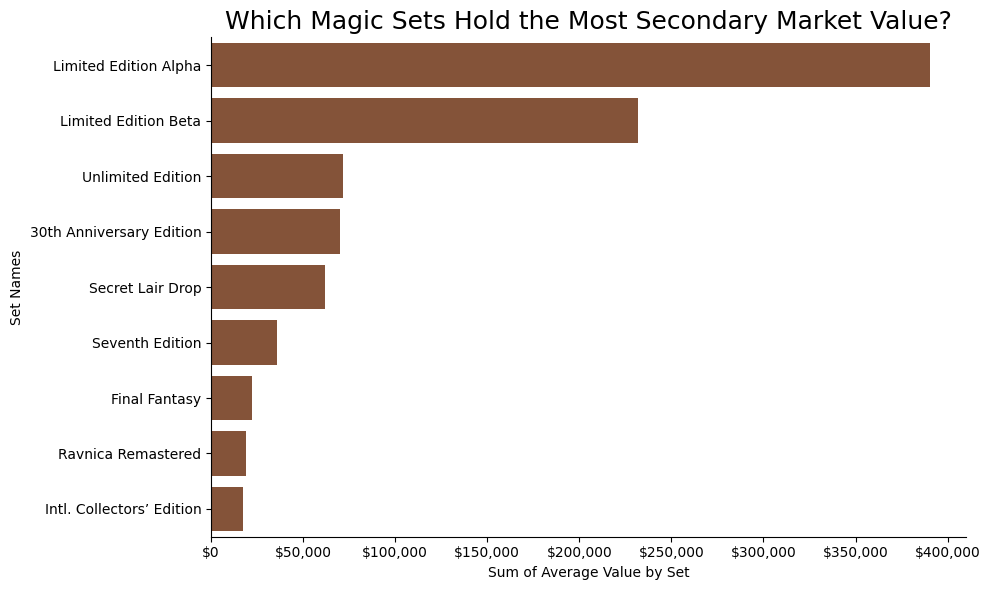

In [19]:
setAvg2 = dfm4.groupby('setName')['avgMarketPrice'].sum().sort_values(ascending = False)

plt.figure(figsize=(10,6))

sns.barplot(setAvg2, color = '#914F2C', width = 0.8, orient = 'h')
plt.title('Which Magic Sets Hold the Most Secondary Market Value?', fontsize=18)
plt.xlabel("Sum of Average Value by Set")
plt.ylabel("Set Names")

ax = plt.gca()
ax.set_ylim([8.5, -0.5])
ax.xaxis.set_major_formatter(tkr.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.despine()
plt.tight_layout()
plt.show()

In [20]:
# group comparison pokemon